<a href="https://colab.research.google.com/github/Deepu9981/FitPulse-Health-Anomaly-Detection-from-Fitness-Devices/blob/main/modul2_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

In [3]:
from google.colab import files
df = files.upload()

Saving FitPulse_final_dataset.csv to FitPulse_final_dataset.csv


In [120]:
data=pd.read_csv('/content/drive/MyDrive/FitPulse Health Anomaly Detection from Fitness Devices/FitPulse_final_dataset.csv')

In [121]:
data.columns

Index(['Patient_ID', 'heart_rate', 'step_count', 'sleep_tracking',
       'time_stamp', 'Weight', 'Height', 'gender', 'age', 'daily_calories',
       'daily_sleep_hours', 'daily_steps', 'resting_heart_rate'],
      dtype='object')

In [122]:
import pandas as pd

# Assuming 'data' is your DataFrame
data["Time"] = pd.to_datetime(data["time_stamp"])

# Create day window
data["day"] = data["Time"].dt.date

# Display the head of the modified DataFrame to show the new columns
display(data[['time_stamp', 'Time', 'day']].head())

,time_stamp,Time,day
0,2025-01-14 16:50:00,2025-01-14 16:50:00,2025-01-14
1,2025-01-21 08:55:00,2025-01-21 08:55:00,2025-01-21
2,2025-01-17 07:10:00,2025-01-17 07:10:00,2025-01-17
3,2025-01-18 18:25:00,2025-01-18 18:25:00,2025-01-18
4,2025-01-13 07:20:00,2025-01-13 07:20:00,2025-01-13


In [124]:
from tsfresh.utilities.dataframe_functions import roll_time_series

value_columns = ["resting_heart_rate", "daily_steps", "daily_sleep_hours"]

tsfresh_input = data.melt(
    id_vars=["Patient_ID", "Time", "day"],
    value_vars=value_columns,
    var_name="kind",
    value_name="value"
)

tsfresh_input = tsfresh_input.rename(columns={
    "day": "id",
    "Time": "time"
})

tsfresh_input = tsfresh_input[["id", "time", "kind", "value"]]

In [125]:
from prophet import Prophet
import pandas as pd

# Prepare your data for Prophet
# Assuming 'data' DataFrame is available from earlier steps
df_prophet = data.rename(columns={
    "time_stamp": "ds",
    "resting_heart_rate": "y" # Or any other metric you want to forecast
})
df_prophet["ds"] = pd.to_datetime(df_prophet["ds"]).dt.tz_localize(None)

# Initialize and fit the Prophet model
model = Prophet()
model.fit(df_prophet)

# Create a future DataFrame for predictions
# You can adjust the 'periods' and 'freq' as needed
future = model.make_future_dataframe(periods=10, freq="min")

# Generate the forecast
forecast = model.predict(future)

print("Forecast variable defined. Here are the first few rows:")
display(forecast.head())

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


Forecast variable defined. Here are the first few rows:


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,daily_lower,daily_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2025-01-01 00:00:00,80.337347,66.184510,95.177445,80.337347,80.337347,0.136479,0.136479,0.136479,-0.012220,-0.012220,-0.012220,0.148699,0.148699,0.148699,0.0,0.0,0.0,80.473826
1,2025-01-01 00:05:00,80.337321,64.523531,96.112551,80.337321,80.337321,0.163726,0.163726,0.163726,0.016685,0.016685,0.016685,0.147041,0.147041,0.147041,0.0,0.0,0.0,80.501047
2,2025-01-01 00:10:00,80.337296,65.040013,94.564040,80.337296,80.337296,0.191656,0.191656,0.191656,0.046297,0.046297,0.046297,0.145359,0.145359,0.145359,0.0,0.0,0.0,80.528951
3,2025-01-01 00:15:00,80.337270,64.677374,95.389738,80.337270,80.337270,0.220147,0.220147,0.220147,0.076494,0.076494,0.076494,0.143653,0.143653,0.143653,0.0,0.0,0.0,80.557417
4,2025-01-01 00:20:00,80.337245,66.628758,96.077327,80.337245,80.337245,0.249075,0.249075,0.249075,0.107151,0.107151,0.107151,0.141924,0.141924,0.141924,0.0,0.0,0.0,80.586320


In [126]:
# Safety cleaning
tsfresh_input.replace([np.inf, -np.inf], np.nan, inplace=True)
tsfresh_input.dropna(inplace=True)

#If infinity / NaN exists → TSFresh WILL FAIL.

In [128]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from tsfresh import extract_features

# Extract features from tsfresh_input
tsfresh_features = extract_features(
    tsfresh_input,
    column_id="id",
    column_sort="time",
    column_kind="kind",
    column_value="value",
    n_jobs=0 # Use n_jobs=0 to avoid multiprocessing issues in Colab
)

# Remove columns with NaN or Inf values after feature extraction, if any
tsfresh_features.replace([np.inf, -np.inf], np.nan, inplace=True)
tsfresh_features.dropna(axis=1, inplace=True)


X = tsfresh_features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10) # Added n_init to suppress future warning
tsfresh_features["cluster"] = kmeans.fit_predict(X_scaled)

Feature Extraction: 100%|██████████| 114/114 [00:21<00:00,  5.23it/s]


In [129]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sil_scores = {}

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    sil_scores[k] = score
    print(f"K={k}, Silhouette Score={score:.3f}")


K=2, Silhouette Score=0.672
K=3, Silhouette Score=0.162
K=4, Silhouette Score=0.155
K=5, Silhouette Score=0.161
K=6, Silhouette Score=0.158


In [130]:
print(tsfresh_features.groupby("cluster").mean())

         daily_sleep_hours__variance_larger_than_standard_deviation  \
cluster                                                               
0                                                      0.0            
1                                                      0.0            
2                                                      0.0            

         daily_sleep_hours__has_duplicate_max  \
cluster                                         
0                                    0.000000   
1                                    0.433333   
2                                    0.000000   

         daily_sleep_hours__has_duplicate_min  \
cluster                                         
0                                         0.0   
1                                         1.0   
2                                         0.0   

         daily_sleep_hours__has_duplicate  daily_sleep_hours__sum_values  \
cluster                                                                    


In [131]:
import plotly.express as px

fig = px.scatter(
    tsfresh_features,
    x="daily_steps__mean",
    y="resting_heart_rate__variance",
    color="cluster",
    title="Behavior Clusters",
    labels={
        "daily_steps__mean": "Mean Daily Steps",
        "resting_heart_rate__variance": "Resting Heart Rate Variance",
        "cluster": "Cluster"
    }
)

fig.show()

# feature extrection

In [132]:
display(data.head())

,Patient_ID,heart_rate,step_count,sleep_tracking,time_stamp,Weight,Height,gender,age,daily_calories,daily_sleep_hours,daily_steps,resting_heart_rate,Time,day
0,P0001,74.499653,26.0,NaN,2025-01-14 16:50:00,88,168,M,22,2808,7.9,8337,72,2025-01-14 16:50:00,2025-01-14
1,P0002,90.833116,6.0,NaN,2025-01-21 08:55:00,78,162,M,20,2719,9.0,9841,86,2025-01-21 08:55:00,2025-01-21
2,P0003,61.270774,40.0,NaN,2025-01-17 07:10:00,64,162,M,58,2761,8.6,8669,63,2025-01-17 07:10:00,2025-01-17
3,P0005,59.807869,29.0,NaN,2025-01-18 18:25:00,70,151,M,38,2854,8.6,9461,91,2025-01-18 18:25:00,2025-01-18
4,P0006,92.702179,34.0,NaN,2025-01-13 07:20:00,88,159,F,63,2017,8.4,6470,93,2025-01-13 07:20:00,2025-01-13


In [133]:
import io
import pandas as pd
from google.colab import files

# Call files.upload() here to ensure uploaded_files_dict is populated correctly
uploaded_files_dict = files.upload()

# Assuming only one file was uploaded, or you want the first one
# Get the filename and content from the uploaded dictionary
filename = list(uploaded_files_dict.keys())[0]
file_content = uploaded_files_dict[filename]

# Read the content into a pandas DataFrame
uploaded_df = pd.read_csv(io.StringIO(file_content.decode('utf-8')))

print(f"Successfully loaded '{filename}' into a DataFrame.")
display(uploaded_df.head())

Saving FitPulse_final_dataset.csv to FitPulse_final_dataset (3).csv
Successfully loaded 'FitPulse_final_dataset (3).csv' into a DataFrame.


,Patient_ID,heart_rate,step_count,sleep_tracking,time_stamp,Weight,Height,gender,age,daily_calories,daily_sleep_hours,daily_steps,resting_heart_rate
0,P0001,74.499653,26.0,NaN,2025-01-14 16:50:00,88,168,M,22,2808,7.9,8337,72
1,P0002,90.833116,6.0,NaN,2025-01-21 08:55:00,78,162,M,20,2719,9.0,9841,86
2,P0003,61.270774,40.0,NaN,2025-01-17 07:10:00,64,162,M,58,2761,8.6,8669,63
3,P0005,59.807869,29.0,NaN,2025-01-18 18:25:00,70,151,M,38,2854,8.6,9461,91
4,P0006,92.702179,34.0,NaN,2025-01-13 07:20:00,88,159,F,63,2017,8.4,6470,93


In [134]:
# Ensure timestamp
uploaded_df['timestamp'] = pd.to_datetime(uploaded_df['time_stamp'])

In [135]:
WINDOW_SIZE = 10    # number of rows per window
STEP_SIZE = 10      # overlap

rows = []
window_id = 0

for start in range(0, len(uploaded_df) - WINDOW_SIZE, STEP_SIZE):
    window = uploaded_df.iloc[start:start + WINDOW_SIZE].copy()
    window["id"] = window_id
    rows.append(window)
    window_id += 1

df_windowed = pd.concat(rows)

In [136]:
print(f"Length of the uploaded_df DataFrame: {len(uploaded_df)}")

Length of the uploaded_df DataFrame: 7909


In [137]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [138]:
# Rename for tsfresh
ts_df = uploaded_df[['Patient_ID', 'time_stamp', 'resting_heart_rate']]
ts_df.columns = ['id', 'time', 'value'
]

In [139]:
# Safety cleaning
ts_df.replace([np.inf, -np.inf], np.nan, inplace=True)
ts_df.dropna(inplace=True)

#If infinity / NaN exists → TSFresh WILL FAIL.

/tmp/ipython-input-134172737.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-134172737.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [140]:
uploaded_df['Patient_ID'].value_counts()

,count
Patient_ID,
P0892,2
P5790,1
P5789,1
P5786,1
P5785,1
...,...
P2893,1
P2892,1
P2891,1


In [141]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=100,
    contamination=0.05, #5%
    random_state=42
)

features_filled = tsfresh_features.fillna(0)

anomaly_labels = model.fit_predict(features_filled)

tsfresh_features['anomaly'] = anomaly_labels

In [142]:
tsfresh_features['anomaly'].value_counts()

,count
anomaly,
1,36
-1,2


In [143]:
display(tsfresh_features.columns)

Index(['daily_sleep_hours__variance_larger_than_standard_deviation',
       'daily_sleep_hours__has_duplicate_max',
       'daily_sleep_hours__has_duplicate_min',
       'daily_sleep_hours__has_duplicate', 'daily_sleep_hours__sum_values',
       'daily_sleep_hours__abs_energy', 'daily_sleep_hours__median',
       'daily_sleep_hours__mean', 'daily_sleep_hours__length',
       'daily_sleep_hours__standard_deviation',
       ...
       'resting_heart_rate__ratio_beyond_r_sigma__r_10',
       'resting_heart_rate__count_above__t_0',
       'resting_heart_rate__count_below__t_0',
       'resting_heart_rate__lempel_ziv_complexity__bins_2',
       'resting_heart_rate__lempel_ziv_complexity__bins_3',
       'resting_heart_rate__lempel_ziv_complexity__bins_5',
       'resting_heart_rate__lempel_ziv_complexity__bins_10',
       'resting_heart_rate__lempel_ziv_complexity__bins_100', 'cluster',
       'anomaly'],
      dtype='object', length=653)

In [144]:
sensor_columns = ['resting_heart_rate', 'daily_steps', 'daily_sleep_hours']

long_df = df_windowed.melt(
    id_vars=['id', 'timestamp'],
    value_vars=sensor_columns,
    var_name='kind',
    value_name='value'
)

long_df.rename(columns={
    'timestamp': 'time'
}, inplace=True)

long_df.replace([np.inf, -np.inf], np.nan, inplace=True)
long_df.dropna(inplace=True)

In [145]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.05, random_state=42)
labels = model.fit_predict(features_filled)

features_filled['anomaly'] = labels

In [146]:
df = uploaded_df
display(df.head())

,Patient_ID,heart_rate,step_count,sleep_tracking,time_stamp,Weight,Height,gender,age,daily_calories,daily_sleep_hours,daily_steps,resting_heart_rate,timestamp
0,P0001,74.499653,26.0,NaN,2025-01-14 16:50:00,88,168,M,22,2808,7.9,8337,72,2025-01-14 16:50:00
1,P0002,90.833116,6.0,NaN,2025-01-21 08:55:00,78,162,M,20,2719,9.0,9841,86,2025-01-21 08:55:00
2,P0003,61.270774,40.0,NaN,2025-01-17 07:10:00,64,162,M,58,2761,8.6,8669,63,2025-01-17 07:10:00
3,P0005,59.807869,29.0,NaN,2025-01-18 18:25:00,70,151,M,38,2854,8.6,9461,91,2025-01-18 18:25:00
4,P0006,92.702179,34.0,NaN,2025-01-13 07:20:00,88,159,F,63,2017,8.4,6470,93,2025-01-13 07:20:00


In [147]:
# First, ensure df has a 'day' column for comparison with features_filled's index
# Assuming 'timestamp' column is already present and in datetime format
if 'day' not in df.columns:
    df['day'] = df['timestamp'].dt.date

# Initialize all entries as normal (1)
df['anomaly'] = 1

# Get the list of anomalous days from features_filled's index
anomalous_days = features_filled.query("anomaly == -1").index.tolist()

# Iterate through anomalous days and mark corresponding rows in df
for day_with_anomaly in anomalous_days:
    df.loc[df['day'] == day_with_anomaly, 'anomaly'] = -1

In [148]:
df['anomaly'].value_counts()

,count
anomaly,
1,7907
-1,2


In [149]:
METRIC_ALIASES = {
    'heart_rate': ['heart_rate', 'resting_heart_rate'],
    'sleep_duration': ['sleep_tracking', 'daily_sleep_hours'],
    'step_count': ['step_count', 'daily_steps']
}

metric_data_cols = []
for canonical, aliases in METRIC_ALIASES.items():
    for col in df.columns:
        if col.lower() in aliases:
            metric_data_cols.append(col)
            break # Found a match for this canonical metric

if metric_data_cols:
    print("Displaying data for identified metric columns in 'df' DataFrame:")
    display(df[metric_data_cols].head())
else:
    print("No metric columns (heart_rate, sleep_duration, step_count) found in the 'df' DataFrame based on METRIC_ALIASES.")

Displaying data for identified metric columns in 'df' DataFrame:


,heart_rate,sleep_tracking,step_count
0,74.499653,NaN,26.0
1,90.833116,NaN,6.0
2,61.270774,NaN,40.0
3,59.807869,NaN,29.0
4,92.702179,NaN,34.0


In [150]:
tsfresh_features

,daily_sleep_hours__variance_larger_than_standard_deviation,daily_sleep_hours__has_duplicate_max,daily_sleep_hours__has_duplicate_min,daily_sleep_hours__has_duplicate,daily_sleep_hours__sum_values,daily_sleep_hours__abs_energy,daily_sleep_hours__median,daily_sleep_hours__mean,daily_sleep_hours__length,daily_sleep_hours__standard_deviation,...,resting_heart_rate__ratio_beyond_r_sigma__r_10,resting_heart_rate__count_above__t_0,resting_heart_rate__count_below__t_0,resting_heart_rate__lempel_ziv_complexity__bins_2,resting_heart_rate__lempel_ziv_complexity__bins_3,resting_heart_rate__lempel_ziv_complexity__bins_5,resting_heart_rate__lempel_ziv_complexity__bins_10,resting_heart_rate__lempel_ziv_complexity__bins_100,cluster,anomaly
2025-01-01,0.0,0.0,1.0,1.0,2106.3,17124.59,8.00,8.070115,261.0,0.696205,...,0.0,1.0,0.0,0.229885,0.283525,0.352490,0.440613,0.570881,1,1
2025-01-02,0.0,0.0,1.0,1.0,2180.0,17835.46,8.20,8.134328,268.0,0.618810,...,0.0,1.0,0.0,0.223881,0.287313,0.358209,0.432836,0.563433,1,1
2025-01-03,0.0,0.0,1.0,1.0,2162.2,17615.90,8.00,8.098127,267.0,0.630466,...,0.0,1.0,0.0,0.224719,0.288390,0.352060,0.434457,0.569288,1,1
2025-01-04,0.0,1.0,1.0,1.0,2035.8,16415.52,8.00,8.014961,254.0,0.623248,...,0.0,1.0,0.0,0.228346,0.287402,0.354331,0.437008,0.562992,1,1
2025-01-05,0.0,1.0,1.0,1.0,2061.0,16628.06,7.90,8.019455,257.0,0.623667,...,0.0,1.0,0.0,0.217899,0.287938,0.354086,0.439689,0.568093,1,1
2025-01-06,0.0,0.0,1.0,1.0,2092.7,16946.83,8.00,8.048846,260.0,0.629437,...,0.0,1.0,0.0,0.226923,0.288462,0.357692,0.438462,0.569231,1,1
2025-01-07,0.0,0.0,1.0,1.0,2130.7,17240.01,8.10,8.040377,265.0,0.639510,...,0.0,1.0,0.0,0.226415,0.290566,0.354717,0.437736,0.562264,1,1
2025-01-08,0.0,0.0,1.0,1.0,2104.4,17060.40,8.10,8.062835,261.0,0.596829,...,0.0,1.0,0.0,0.226054,0.287356,0.352490,0.436782,0.567050,1,1
2025-01-09,0.0,1.0,1.0,1.0,2187.8,17918.22,8.10,8.133086,269.0,0.680737,...,0.0,1.0,0.0,0.226766,0.286245,0.353160,0.442379,0.565056,1,1
2025-01-10,0.0,1.0,1.0,1.0,2133.9,17356.23,8.10,8.082955,264.0,0.639642,...,0.0,1.0,0.0,0.227273,0.284091,0.352273,0.435606,0.564394,1,1


In [153]:
tsfresh_features.to_csv("tsfresh_features.csv")
files.download("tsfresh_features.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [154]:
import pandas as pd
import numpy as np
from tsfresh import extract_features
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Select 5 unique Patient_IDs
five_patient_ids = data['Patient_ID'].unique()[:5]

# 2. Filter the original data for these 5 patients
data_5_users = data[data['Patient_ID'].isin(five_patient_ids)].copy()

# Ensure 'Time' column is datetime for sorting
data_5_users['Time'] = pd.to_datetime(data_5_users['time_stamp'])

# 3. Prepare tsfresh_input for these 5 users, with 'Patient_ID' as the ID column
value_columns_for_patients = ["resting_heart_rate", "daily_steps", "daily_sleep_hours"]

tsfresh_input_5_users = data_5_users.melt(
    id_vars=["Patient_ID", "Time"], # Use Patient_ID as ID, and Time for sorting
    value_vars=value_columns_for_patients,
    var_name="kind",
    value_name="value"
)

tsfresh_input_5_users = tsfresh_input_5_users.rename(columns={
    "Patient_ID": "id", # Now 'id' is Patient_ID
    "Time": "time"      # 'time' is the actual timestamp for sorting
})

tsfresh_input_5_users = tsfresh_input_5_users[["id", "time", "kind", "value"]]

# Safety cleaning (as before for tsfresh)
tsfresh_input_5_users.replace([np.inf, -np.inf], np.nan, inplace=True)
tsfresh_input_5_users.dropna(inplace=True)

print("Prepared data for 5 users for TSFresh feature extraction:")
display(tsfresh_input_5_users.head())

Prepared data for 5 users for TSFresh feature extraction:


,id,time,kind,value
0,P0001,2025-01-14 16:50:00,resting_heart_rate,72.0
1,P0002,2025-01-21 08:55:00,resting_heart_rate,86.0
2,P0003,2025-01-17 07:10:00,resting_heart_rate,63.0
3,P0005,2025-01-18 18:25:00,resting_heart_rate,91.0
4,P0006,2025-01-13 07:20:00,resting_heart_rate,93.0


In [155]:
# Extract features from tsfresh_input_5_users
tsfresh_features_5_users = extract_features(
    tsfresh_input_5_users,
    column_id="id", # ID is Patient_ID
    column_sort="time",
    column_kind="kind",
    column_value="value",
    n_jobs=0 # Use n_jobs=0 to avoid multiprocessing issues in Colab
)

# Remove columns with NaN or Inf values after feature extraction
tsfresh_features_5_users.replace([np.inf, -np.inf], np.nan, inplace=True)
tsfresh_features_5_users.dropna(axis=1, inplace=True)

print("Extracted features for 5 users:")
display(tsfresh_features_5_users.head())

Feature Extraction: 100%|██████████| 15/15 [00:01<00:00, 13.81it/s]

Extracted features for 5 users:


,daily_sleep_hours__variance_larger_than_standard_deviation,daily_sleep_hours__has_duplicate_max,daily_sleep_hours__has_duplicate_min,daily_sleep_hours__has_duplicate,daily_sleep_hours__sum_values,daily_sleep_hours__abs_energy,daily_sleep_hours__median,daily_sleep_hours__mean,daily_sleep_hours__length,daily_sleep_hours__standard_deviation,...,resting_heart_rate__ratio_beyond_r_sigma__r_6,resting_heart_rate__ratio_beyond_r_sigma__r_7,resting_heart_rate__ratio_beyond_r_sigma__r_10,resting_heart_rate__count_above__t_0,resting_heart_rate__count_below__t_0,resting_heart_rate__lempel_ziv_complexity__bins_2,resting_heart_rate__lempel_ziv_complexity__bins_3,resting_heart_rate__lempel_ziv_complexity__bins_5,resting_heart_rate__lempel_ziv_complexity__bins_10,resting_heart_rate__lempel_ziv_complexity__bins_100
P0001,0.0,0.0,0.0,0.0,7.9,62.41,7.9,7.9,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
P0002,0.0,0.0,0.0,0.0,9.0,81.00,9.0,9.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
P0003,0.0,0.0,0.0,0.0,8.6,73.96,8.6,8.6,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
P0005,0.0,0.0,0.0,0.0,8.6,73.96,8.6,8.6,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
P0006,0.0,0.0,0.0,0.0,8.4,70.56,8.4,8.4,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0


In [156]:
# Scale the features
X_5_users = tsfresh_features_5_users
scaler_5_users = StandardScaler()
X_scaled_5_users = scaler_5_users.fit_transform(X_5_users)

# Apply KMeans clustering
kmeans_5_users = KMeans(n_clusters=3, random_state=42, n_init=10) # Added n_init
tsfresh_features_5_users["cluster"] = kmeans_5_users.fit_predict(X_scaled_5_users)

print("Clustering results for 5 users:")
display(tsfresh_features_5_users[['cluster']].head())

Clustering results for 5 users:


,cluster
P0001,2
P0002,0
P0003,2
P0005,0
P0006,1


In [157]:
from sklearn.metrics import silhouette_score

sil_scores_5_users = {}

for k in range(2, min(len(X_scaled_5_users), 5)): # Max k is min(num_samples, 5)
    if k < 2:
        continue
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled_5_users)

    score = silhouette_score(X_scaled_5_users, labels)
    sil_scores_5_users[k] = score
    print(f"K={k}, Silhouette Score={score:.3f}")

if sil_scores_5_users:
    best_k = max(sil_scores_5_users, key=sil_scores_5_users.get)
    print(f"\nOptimal K (based on Silhouette Score) for 5 users: {best_k}")
else:
    print("Not enough samples to compute silhouette scores for multiple clusters.")

K=2, Silhouette Score=0.251
K=3, Silhouette Score=0.299
K=4, Silhouette Score=0.198

Optimal K (based on Silhouette Score) for 5 users: 3


In [158]:
df_prophet = data.rename(columns={
    "time_stamp": "ds",
    "resting_heart_rate": "y"
})

df_prophet["ds"] = pd.to_datetime(df_prophet["ds"]).dt.tz_localize(None)

In [160]:
print("Here are the key columns from your forecast:")
display(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())

Here are the key columns from your forecast:


,ds,yhat,yhat_lower,yhat_upper
0,2025-01-01 00:00:00,80.473826,66.184510,95.177445
1,2025-01-01 00:05:00,80.501047,64.523531,96.112551
2,2025-01-01 00:10:00,80.528951,65.040013,94.564040
3,2025-01-01 00:15:00,80.557417,64.677374,95.389738
4,2025-01-01 00:20:00,80.586320,66.628758,96.077327


In [162]:
from prophet import Prophet
import pandas as pd

df_prophet = data.rename(columns={
    "time_stamp": "ds",
    "resting_heart_rate": "y"
})

df_prophet["ds"] = pd.to_datetime(df_prophet["ds"]).dt.tz_localize(None)

model = Prophet()
model.fit(df_prophet)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


In [164]:
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,daily_lower,daily_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2025-01-01 00:00:00,80.337347,66.184510,95.177445,80.337347,80.337347,0.136479,0.136479,0.136479,-0.012220,-0.012220,-0.012220,0.148699,0.148699,0.148699,0.0,0.0,0.0,80.473826
1,2025-01-01 00:05:00,80.337321,64.523531,96.112551,80.337321,80.337321,0.163726,0.163726,0.163726,0.016685,0.016685,0.016685,0.147041,0.147041,0.147041,0.0,0.0,0.0,80.501047
2,2025-01-01 00:10:00,80.337296,65.040013,94.564040,80.337296,80.337296,0.191656,0.191656,0.191656,0.046297,0.046297,0.046297,0.145359,0.145359,0.145359,0.0,0.0,0.0,80.528951
3,2025-01-01 00:15:00,80.337270,64.677374,95.389738,80.337270,80.337270,0.220147,0.220147,0.220147,0.076494,0.076494,0.076494,0.143653,0.143653,0.143653,0.0,0.0,0.0,80.557417
4,2025-01-01 00:20:00,80.337245,66.628758,96.077327,80.337245,80.337245,0.249075,0.249075,0.249075,0.107151,0.107151,0.107151,0.141924,0.141924,0.141924,0.0,0.0,0.0,80.586320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7887,2025-12-01 00:16:00,77.873188,63.302210,92.616298,77.873188,77.873188,0.570978,0.570978,0.570978,0.082593,0.082593,0.082593,0.488385,0.488385,0.488385,0.0,0.0,0.0,78.444165
7888,2025-12-01 00:17:00,77.873182,62.308383,92.829013,77.873182,77.873182,0.576065,0.576065,0.576065,0.088709,0.088709,0.088709,0.487356,0.487356,0.487356,0.0,0.0,0.0,78.449247
7889,2025-12-01 00:18:00,77.873177,63.222999,92.999233,77.873177,77.873177,0.581167,0.581167,0.581167,0.094841,0.094841,0.094841,0.486326,0.486326,0.486326,0.0,0.0,0.0,78.454344
7890,2025-12-01 00:19:00,77.873172,63.315010,93.481209,77.873172,77.873172,0.586285,0.586285,0.586285,0.100989,0.100989,0.100989,0.485296,0.485296,0.485296,0.0,0.0,0.0,78.459457


In [165]:
display(forecast.head())

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,daily_lower,daily_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2025-01-01 00:00:00,80.337347,66.184510,95.177445,80.337347,80.337347,0.136479,0.136479,0.136479,-0.012220,-0.012220,-0.012220,0.148699,0.148699,0.148699,0.0,0.0,0.0,80.473826
1,2025-01-01 00:05:00,80.337321,64.523531,96.112551,80.337321,80.337321,0.163726,0.163726,0.163726,0.016685,0.016685,0.016685,0.147041,0.147041,0.147041,0.0,0.0,0.0,80.501047
2,2025-01-01 00:10:00,80.337296,65.040013,94.564040,80.337296,80.337296,0.191656,0.191656,0.191656,0.046297,0.046297,0.046297,0.145359,0.145359,0.145359,0.0,0.0,0.0,80.528951
3,2025-01-01 00:15:00,80.337270,64.677374,95.389738,80.337270,80.337270,0.220147,0.220147,0.220147,0.076494,0.076494,0.076494,0.143653,0.143653,0.143653,0.0,0.0,0.0,80.557417
4,2025-01-01 00:20:00,80.337245,66.628758,96.077327,80.337245,80.337245,0.249075,0.249075,0.249075,0.107151,0.107151,0.107151,0.141924,0.141924,0.141924,0.0,0.0,0.0,80.586320


In [166]:
future = model.make_future_dataframe(periods=10, freq="min")
forecast = model.predict(future)
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

                      ds       yhat  yhat_lower  yhat_upper
7887 2025-12-01 00:16:00  78.444165   62.963906   93.655861
7888 2025-12-01 00:17:00  78.449247   63.786500   94.037059
7889 2025-12-01 00:18:00  78.454344   63.330115   93.552026
7890 2025-12-01 00:19:00  78.459457   63.693863   92.045630
7891 2025-12-01 00:20:00  78.464583   63.387722   93.922104


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


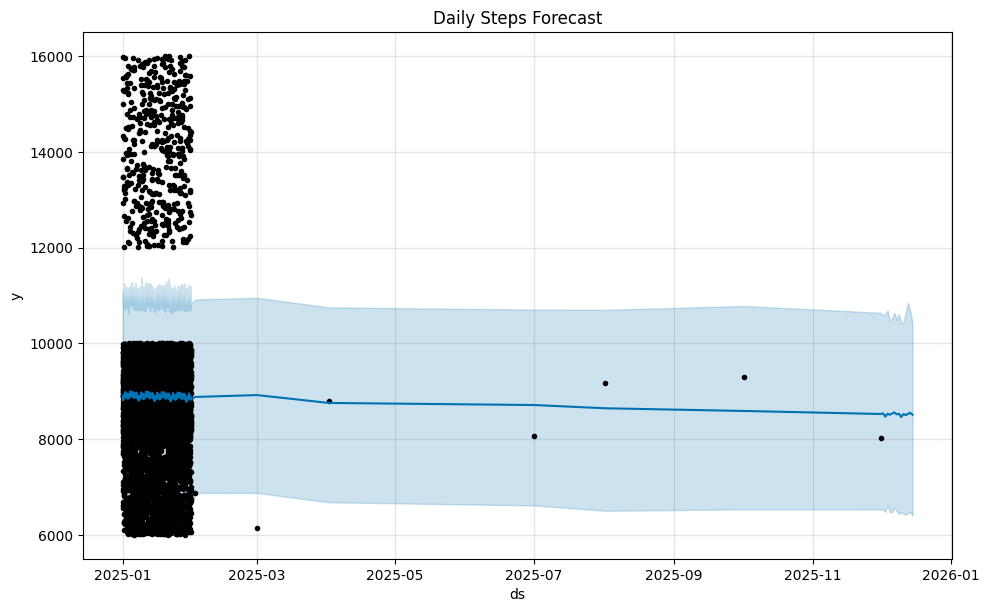

In [167]:
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt

# Prepare data
df_steps = data[['time_stamp', 'daily_steps']].rename(
    columns={'time_stamp': 'ds', 'daily_steps': 'y'}
)
df_steps['ds'] = pd.to_datetime(df_steps['ds']).dt.tz_localize(None)

# Train model
model_steps = Prophet()
model_steps.fit(df_steps)

# Predict
future_steps = model_steps.make_future_dataframe(periods=14, freq='D')
forecast_steps = model_steps.predict(future_steps)

# Plot
model_steps.plot(forecast_steps)
plt.title('Daily Steps Forecast')
plt.show()

In [170]:

print("First 5 rows of extracted features:")
display(tsfresh_features.head())
print("\nShape of extracted features:")
print(tsfresh_features.shape)


First 5 rows of extracted features:


,daily_sleep_hours__variance_larger_than_standard_deviation,daily_sleep_hours__has_duplicate_max,daily_sleep_hours__has_duplicate_min,daily_sleep_hours__has_duplicate,daily_sleep_hours__sum_values,daily_sleep_hours__abs_energy,daily_sleep_hours__median,daily_sleep_hours__mean,daily_sleep_hours__length,daily_sleep_hours__standard_deviation,...,resting_heart_rate__ratio_beyond_r_sigma__r_10,resting_heart_rate__count_above__t_0,resting_heart_rate__count_below__t_0,resting_heart_rate__lempel_ziv_complexity__bins_2,resting_heart_rate__lempel_ziv_complexity__bins_3,resting_heart_rate__lempel_ziv_complexity__bins_5,resting_heart_rate__lempel_ziv_complexity__bins_10,resting_heart_rate__lempel_ziv_complexity__bins_100,cluster,anomaly
2025-01-01,0.0,0.0,1.0,1.0,2106.3,17124.59,8.0,8.070115,261.0,0.696205,...,0.0,1.0,0.0,0.229885,0.283525,0.352490,0.440613,0.570881,1,1
2025-01-02,0.0,0.0,1.0,1.0,2180.0,17835.46,8.2,8.134328,268.0,0.618810,...,0.0,1.0,0.0,0.223881,0.287313,0.358209,0.432836,0.563433,1,1
2025-01-03,0.0,0.0,1.0,1.0,2162.2,17615.90,8.0,8.098127,267.0,0.630466,...,0.0,1.0,0.0,0.224719,0.288390,0.352060,0.434457,0.569288,1,1
2025-01-04,0.0,1.0,1.0,1.0,2035.8,16415.52,8.0,8.014961,254.0,0.623248,...,0.0,1.0,0.0,0.228346,0.287402,0.354331,0.437008,0.562992,1,1
2025-01-05,0.0,1.0,1.0,1.0,2061.0,16628.06,7.9,8.019455,257.0,0.623667,...,0.0,1.0,0.0,0.217899,0.287938,0.354086,0.439689,0.568093,1,1



Shape of extracted features:
(38, 653)


In [172]:
df_resting_heart_rate = data[['time_stamp', 'resting_heart_rate']].copy()
df_resting_heart_rate = df_resting_heart_rate.rename(columns={'time_stamp': 'ds', 'resting_heart_rate': 'y'})
df_resting_heart_rate['ds'] = pd.to_datetime(df_resting_heart_rate['ds']).dt.tz_localize(None)
df_resting_heart_rate = df_resting_heart_rate.set_index('ds').resample('D').mean().reset_index()

print("Prepared df_resting_heart_rate DataFrame:")
display(df_resting_heart_rate.head())

Prepared df_resting_heart_rate DataFrame:


,ds,y
0,2025-01-01,80.107280
1,2025-01-02,80.231343
2,2025-01-03,79.880150
3,2025-01-04,79.393701
4,2025-01-05,82.027237


In [173]:
from prophet import Prophet

model_resting_heart_rate = Prophet(daily_seasonality=True)
model_resting_heart_rate.fit(df_resting_heart_rate)

future_resting_heart_rate = model_resting_heart_rate.make_future_dataframe(periods=5, freq='D')
forecast_resting_heart_rate = model_resting_heart_rate.predict(future_resting_heart_rate)

print("Next 5 daily forecasts for Resting Heart Rate:")
display(forecast_resting_heart_rate[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


Next 5 daily forecasts for Resting Heart Rate:


,ds,yhat,yhat_lower,yhat_upper
335,2025-12-02,71.682242,64.277507,78.548932
336,2025-12-03,73.867615,67.337754,80.940912
337,2025-12-04,76.574468,69.306657,83.691955
338,2025-12-05,73.792586,67.010059,81.073047
339,2025-12-06,74.461990,67.401966,82.133645


In [174]:
df_daily_steps = data[['time_stamp', 'daily_steps']].copy()
df_daily_steps = df_daily_steps.rename(columns={'time_stamp': 'ds', 'daily_steps': 'y'})
df_daily_steps['ds'] = pd.to_datetime(df_daily_steps['ds']).dt.tz_localize(None)
df_daily_steps = df_daily_steps.set_index('ds').resample('D').mean().reset_index()

print("Prepared df_daily_steps DataFrame:")
display(df_daily_steps.head())

Prepared df_daily_steps DataFrame:


,ds,y
0,2025-01-01,9106.735632
1,2025-01-02,8920.074627
2,2025-01-03,9004.812734
3,2025-01-04,8811.090551
4,2025-01-05,8849.276265


In [175]:
model_daily_steps = Prophet(daily_seasonality=True)
model_daily_steps.fit(df_daily_steps)

future_daily_steps = model_daily_steps.make_future_dataframe(periods=5, freq='D')
forecast_daily_steps = model_daily_steps.predict(future_daily_steps)

print("Next 5 daily forecasts for Daily Steps:")
display(forecast_daily_steps[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


Next 5 daily forecasts for Daily Steps:


,ds,yhat,yhat_lower,yhat_upper
335,2025-12-02,8256.125361,7610.721976,8917.518937
336,2025-12-03,8490.570556,7866.667381,9179.185673
337,2025-12-04,8355.008199,7716.047595,9034.704589
338,2025-12-05,8601.341952,7933.166283,9275.233995
339,2025-12-06,7618.744053,6926.806905,8270.680496


In [177]:
df_daily_sleep_hours = data[['time_stamp', 'daily_sleep_hours']].copy()
df_daily_sleep_hours = df_daily_sleep_hours.rename(columns={'time_stamp': 'ds', 'daily_sleep_hours': 'y'})
df_daily_sleep_hours['ds'] = pd.to_datetime(df_daily_sleep_hours['ds']).dt.tz_localize(None)
df_daily_sleep_hours = df_daily_sleep_hours.set_index('ds').resample('D').mean().reset_index()

print("Prepared df_daily_sleep_hours DataFrame:")
display(df_daily_sleep_hours.head())

Prepared df_daily_sleep_hours DataFrame:


,ds,y
0,2025-01-01,8.070115
1,2025-01-02,8.134328
2,2025-01-03,8.098127
3,2025-01-04,8.014961
4,2025-01-05,8.019455


In [178]:
from prophet import Prophet

model_daily_sleep_hours = Prophet(daily_seasonality=True)
model_daily_sleep_hours.fit(df_daily_sleep_hours)

future_daily_sleep_hours = model_daily_sleep_hours.make_future_dataframe(periods=5, freq='D')
forecast_daily_sleep_hours = model_daily_sleep_hours.predict(future_daily_sleep_hours)

print("Next 5 daily forecasts for Daily Sleep Hours:")
display(forecast_daily_sleep_hours[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


Next 5 daily forecasts for Daily Sleep Hours:


,ds,yhat,yhat_lower,yhat_upper
335,2025-12-02,7.927100,7.620742,8.268745
336,2025-12-03,8.096867,7.782054,8.444668
337,2025-12-04,8.206064,7.892458,8.521343
338,2025-12-05,8.089811,7.753935,8.398639
339,2025-12-06,8.139343,7.836172,8.462996


In [179]:
print("Final 5 daily forecasts for Resting Heart Rate:")
display(forecast_resting_heart_rate[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

print("\nFinal 5 daily forecasts for Daily Steps:")
display(forecast_daily_steps[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

print("\nFinal 5 daily forecasts for Daily Sleep Hours:")
display(forecast_daily_sleep_hours[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

Final 5 daily forecasts for Resting Heart Rate:


,ds,yhat,yhat_lower,yhat_upper
335,2025-12-02,71.682242,64.277507,78.548932
336,2025-12-03,73.867615,67.337754,80.940912
337,2025-12-04,76.574468,69.306657,83.691955
338,2025-12-05,73.792586,67.010059,81.073047
339,2025-12-06,74.461990,67.401966,82.133645



Final 5 daily forecasts for Daily Steps:


,ds,yhat,yhat_lower,yhat_upper
335,2025-12-02,8256.125361,7610.721976,8917.518937
336,2025-12-03,8490.570556,7866.667381,9179.185673
337,2025-12-04,8355.008199,7716.047595,9034.704589
338,2025-12-05,8601.341952,7933.166283,9275.233995
339,2025-12-06,7618.744053,6926.806905,8270.680496



Final 5 daily forecasts for Daily Sleep Hours:


,ds,yhat,yhat_lower,yhat_upper
335,2025-12-02,7.927100,7.620742,8.268745
336,2025-12-03,8.096867,7.782054,8.444668
337,2025-12-04,8.206064,7.892458,8.521343
338,2025-12-05,8.089811,7.753935,8.398639
339,2025-12-06,8.139343,7.836172,8.462996


In [184]:
import plotly.graph_objects as go

fig = go.Figure()

# Add a scatter plot trace for the actual 'resting_heart_rate' data
fig.add_trace(go.Scatter(
    x=df_resting_heart_rate['ds'],
    y=df_resting_heart_rate['y'],
    mode='lines',
    name='Actual'
))

# Add a scatter plot trace for the forecasted 'resting_heart_rate' trend (yhat)
fig.add_trace(go.Scatter(
    x=forecast_resting_heart_rate['ds'],
    y=forecast_resting_heart_rate['yhat'],
    mode='lines',
    name='Forecast'
))

# Add the prediction interval as a single fill trace
fig.add_trace(go.Scatter(
    x=forecast_resting_heart_rate['ds'].tolist() + forecast_resting_heart_rate['ds'].tolist()[::-1], # x, then x reversed
    y=forecast_resting_heart_rate['yhat_upper'].tolist() + forecast_resting_heart_rate['yhat_lower'].tolist()[::-1], # upper, then lower reversed
    fill='toself',
    fillcolor='rgba(255,0,0,0.2)',
    line=dict(color='rgba(255,255,255,0)'), # Invisible line for the boundary
    hoverinfo='skip',
    name='Prediction Interval',
    showlegend=True
))

# Update the layout of the figure
fig.update_layout(
    title='Resting Heart Rate Forecast',
    xaxis_title='Date',
    yaxis_title='Resting Heart Rate (bpm)',
    hovermode='x unified'
)

# Display the figure
fig.show()

In [187]:
import plotly.graph_objects as go

# Create a go.Figure() object for Daily Steps
fig_steps = go.Figure()

# Add a scatter plot trace for the actual 'daily_steps' data
fig_steps.add_trace(go.Scatter(
    x=df_daily_steps['ds'],
    y=df_daily_steps['y'],
    mode='lines',
    name='Actual'
))

# Add a scatter plot trace for the forecasted 'daily_steps' trend (yhat)
fig_steps.add_trace(go.Scatter(
    x=forecast_daily_steps['ds'],
    y=forecast_daily_steps['yhat'],
    mode='lines',
    name='Forecast'
))

# Add a fill area trace to represent the prediction interval for 'daily_steps'
fig_steps.add_trace(go.Scatter(
    x=forecast_daily_steps['ds'],
    y=forecast_daily_steps['yhat_upper'],
    mode='lines',
    line=dict(width=0),
    showlegend=False,
    hoverinfo='skip',
    name='Upper Bound'
))
fig_steps.add_trace(go.Scatter(
    x=forecast_daily_steps['ds'],
    y=forecast_daily_steps['yhat_lower'],
    mode='lines',
    line=dict(width=0),
    fill='tonexty',
    fillcolor='rgba(0,0,255,0.2)', # Using a different color for clarity
    name='Prediction Interval'
))

# Update the layout of the figure
fig_steps.update_layout(
    title='Daily Steps Forecast',
    xaxis_title='Date',
    yaxis_title='Daily Steps',
    hovermode='x unified'
)

# Display the figure
fig_steps.show()

In [188]:
import plotly.graph_objects as go

# Create a go.Figure() object for Daily Sleep Hours
fig_sleep = go.Figure()

# Add a scatter plot trace for the actual 'daily_sleep_hours' data
fig_sleep.add_trace(go.Scatter(
    x=df_daily_sleep_hours['ds'],
    y=df_daily_sleep_hours['y'],
    mode='lines',
    name='Actual'
))

# Add a scatter plot trace for the forecasted 'daily_sleep_hours' trend (yhat)
fig_sleep.add_trace(go.Scatter(
    x=forecast_daily_sleep_hours['ds'],
    y=forecast_daily_sleep_hours['yhat'],
    mode='lines',
    name='Forecast'
))

# Add a fill area trace to represent the prediction interval for 'daily_sleep_hours'
fig_sleep.add_trace(go.Scatter(
    x=forecast_daily_sleep_hours['ds'],
    y=forecast_daily_sleep_hours['yhat_upper'],
    mode='lines',
    line=dict(width=0),
    showlegend=False,
    hoverinfo='skip',
    name='Upper Bound'
))
fig_sleep.add_trace(go.Scatter(
    x=forecast_daily_sleep_hours['ds'],
    y=forecast_daily_sleep_hours['yhat_lower'],
    mode='lines',
    line=dict(width=0),
    fill='tonexty',
    fillcolor='rgba(0,255,0,0.2)', # Using a different color for clarity
    name='Prediction Interval'
))

# Update the layout of the figure
fig_sleep.update_layout(
    title='Daily Sleep Hours Forecast',
    xaxis_title='Date',
    yaxis_title='Daily Sleep Hours',
    hovermode='x unified'
)

# Display the figure
fig_sleep.show()